In [22]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
from statsmodels.tools import add_constant

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# **Data Preparation**

In [5]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
try:
    df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/car_purchasing.csv", encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/car_purchasing.csv", encoding='latin1')

In [7]:
# Display (Look into) the first 5 entries and last 5 entries of dataset.
display(df.head())
print()
display(df.tail())

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
495,Walter,ligula@Cumsociis.ca,Nepal,0,41.462515,71942.40291,6995.902524,541670.1016,48901.44342
496,Vanna,Cum.sociis.natoque@Sedmolestie.edu,Zimbabwe,1,37.642000,56039.49793,12301.456790,360419.0988,31491.41457
497,Pearl,penatibus.et@massanonante.com,Philippines,1,53.943497,68888.77805,10611.606860,764531.3203,64147.28888
498,Nell,Quisque.varius@arcuVivamussit.net,Botswana,1,59.160509,49811.99062,14013.034510,337826.6382,45442.15353
499,Marla,Camaron.marla@hotmail.com,marlal,1,46.731152,61370.67766,9391.341628,462946.4924,45107.22566


In [8]:
# Find the dimensionality of dataset
print("Dimensionality of dataset (rows, columns):", df.shape)

Dimensionality of dataset (rows, columns): (500, 9)


In [9]:
# Statistical summary of numerical variables
print("======================== Dataset Summary ========================")
df.info()

print("\n======================== Statistical Summary ========================")
display(df.describe())

======================== Dataset Summary ========================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    object 
 1   customer e-mail      500 non-null    object 
 2   country              500 non-null    object 
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 35.3+ KB

======================== Statistical Summary ========================


,gender,age,annual Salary,credit card debt,net worth,car purchase amount
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.506000,46.241674,62127.239608,9607.645049,431475.713625,44209.799218
std,0.500465,7.978862,11703.378228,3489.187973,173536.756340,10773.178744
min,0.000000,20.000000,20000.000000,100.000000,20000.000000,9000.000000
25%,0.000000,40.949969,54391.977195,7397.515792,299824.195900,37629.896040
50%,1.000000,46.049901,62915.497035,9655.035568,426750.120650,43997.783390
75%,1.000000,51.612263,70117.862005,11798.867487,557324.478725,51254.709517
max,1.000000,70.000000,100000.000000,20000.000000,1000000.000000,80000.000000


In [10]:
# Identify the null Value and NAN values (missing values) from the dataset, and remove it or fill it decide it based upon your conclusion.

print("No. of missing values BEFORE cleaning:\n", df.isnull().sum())

df.fillna(0, inplace=True)

print("\nNo. of missing values AFTER cleaning:\n", df.isnull().sum())

No. of missing values BEFORE cleaning:
 customer name          0
customer e-mail        0
country                0
gender                 0
age                    0
annual Salary          0
credit card debt       0
net worth              0
car purchase amount    0
dtype: int64

No. of missing values AFTER cleaning:
 customer name          0
customer e-mail        0
country                0
gender                 0
age                    0
annual Salary          0
credit card debt       0
net worth              0
car purchase amount    0
dtype: int64


In [11]:
# Check the duplicate values

print("No. of duplicate rows: ", df.duplicated().sum())
df.drop_duplicates(inplace=True)

No. of duplicate rows:  0


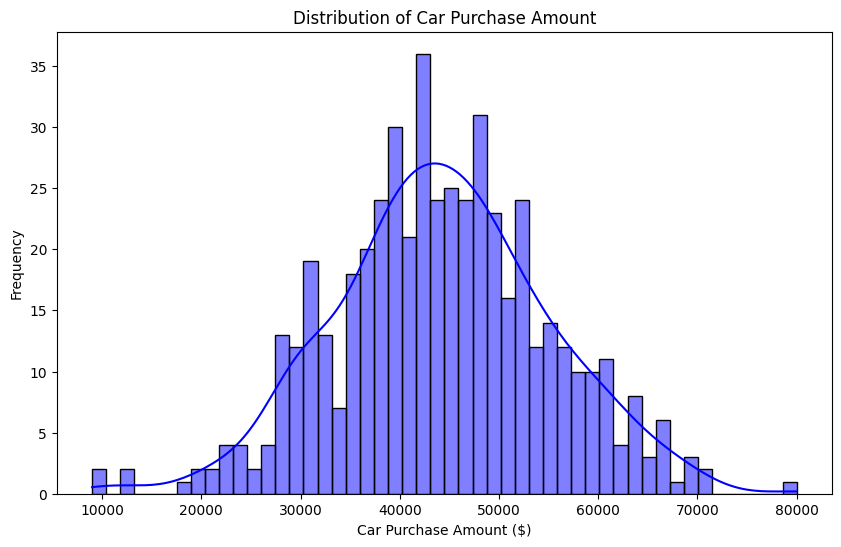

In [13]:
# Count the Purchase distribution. If data is imbalanced, your model may become biased. So resolve it if data is biased.
plt.figure(figsize=(10,6))
sns.histplot(df['car purchase amount'], bins=50, kde=True, color='blue')
plt.title('Distribution of Car Purchase Amount')
plt.xlabel('Car Purchase Amount ($)')
plt.ylabel('Frequency')
plt.show()

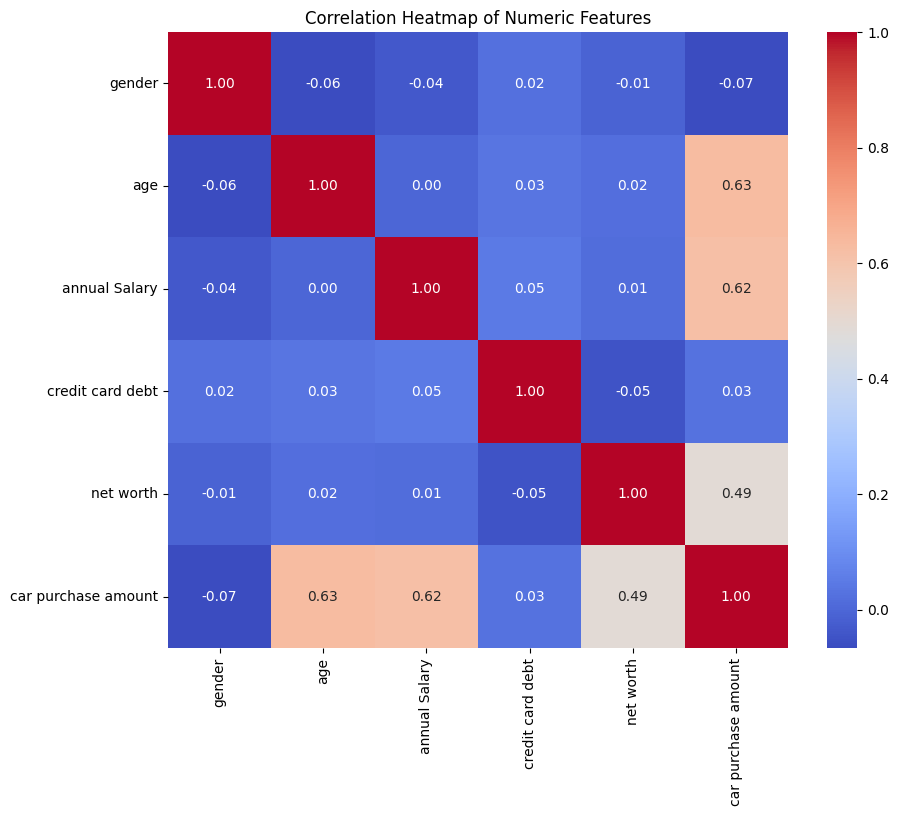

In [14]:
# Data Visualisation: Correlation Heatmap
# Select only numeric columns to avoid errors with string data like 'country'
numeric_cols = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt='.2f')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [15]:
# Declare feature vector and target variable
# Set the target variable (y)
y = df['car purchase amount']

# Set the feature vector (X) by dropping the target and non-predictive string columns
X = df.drop(['car purchase amount', 'customer name', 'customer e-mail'], axis=1)

# Encode the 'country' categorical column into dummy/indicator variables
X = pd.get_dummies(X, drop_first=True)

print("Features Shape after Encoding:", X.shape)
display(X.head())

Features Shape after Encoding: (500, 215)


,gender,age,annual Salary,credit card debt,net worth,country_Algeria,country_American Samoa,country_Andorra,country_Angola,country_Anguilla,...,country_Venezuela,country_Viet Nam,"country_Virgin Islands, British","country_Virgin Islands, United States",country_Wallis and Futuna,country_Western Sahara,country_Yemen,country_Zimbabwe,country_marlal,country_Åland Islands
0,0,41.851720,62812.09301,11609.380910,238961.2505,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,40.870623,66646.89292,9572.957136,530973.9078,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,43.152897,53798.55112,11160.355060,638467.1773,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,58.271369,79370.03798,14426.164850,548599.0524,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,57.313749,59729.15130,5358.712177,560304.0671,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
# Normalize the features through feature scaling
scaler = MinMaxScaler()

# Fit and transform the feature vector
X_scaled_arr = scaler.fit_transform(X)

# Convert back to a DataFrame to maintain column names
X_scaled = pd.DataFrame(X_scaled_arr, columns=X.columns)

display(X_scaled.head())

,gender,age,annual Salary,credit card debt,net worth,country_Algeria,country_American Samoa,country_Andorra,country_Angola,country_Anguilla,...,country_Venezuela,country_Viet Nam,"country_Virgin Islands, British","country_Virgin Islands, United States",country_Wallis and Futuna,country_Western Sahara,country_Yemen,country_Zimbabwe,country_marlal,country_Åland Islands
0,0.0,0.437034,0.535151,0.578361,0.223430,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.417412,0.583086,0.476028,0.521402,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.463058,0.422482,0.555797,0.631089,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.765427,0.742125,0.719908,0.539387,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.746275,0.496614,0.264257,0.551331,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# If the data is biased then add the biasness (constant)
# Adding a constant is required for models like Ordinary Least Squares (OLS) in statsmodels
X_const = add_constant(X_scaled)

display(X_const.head())

,const,gender,age,annual Salary,credit card debt,net worth,country_Algeria,country_American Samoa,country_Andorra,country_Angola,...,country_Venezuela,country_Viet Nam,"country_Virgin Islands, British","country_Virgin Islands, United States",country_Wallis and Futuna,country_Western Sahara,country_Yemen,country_Zimbabwe,country_marlal,country_Åland Islands
0,1.0,0.0,0.437034,0.535151,0.578361,0.223430,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.417412,0.583086,0.476028,0.521402,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.463058,0.422482,0.555797,0.631089,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,0.765427,0.742125,0.719908,0.539387,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,0.746275,0.496614,0.264257,0.551331,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **Model Training**

In [20]:
# Split the dataset into training and testing sets
# We are using test_size=0.2 for an 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X_const, y, test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

Training features shape: (400, 216)
Testing features shape: (100, 216)


In [23]:
# Train an appropriate machine learning model to predict prices
# We using Linear Regression for continuous numerical prediction
lr_model = LinearRegression()

# Fit the model strictly to the training data
lr_model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [24]:
# Make predictions on the test data
y_pred = lr_model.predict(X_test)

# Evaluate the model using suitable performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("================= Model Evaluation =================")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")
print("====================================================")

================= Model Evaluation =================
Mean Squared Error (MSE): 2.82
Root Mean Squared Error (RMSE): 1.68
R-squared (R2) Score: 1.0000


In [26]:
# Interpret the predictions and results
print("================= Feature Impacts (Coefficients) =================")

# Create a DataFrame to view the features and their corresponding coefficients
coefficients_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Impact on Purchase Amount (Coefficient)': lr_model.coef_
})

# Sort by the highest impact
coefficients_df = coefficients_df.sort_values(by='Impact on Purchase Amount (Coefficient)', ascending=False)
display(coefficients_df)

print("\nInterpretation:")
print("Features with large positive coefficients heavily increase the predicted car purchase amount.")
print("Features with large negative coefficients decrease the predicted amount.")
print("Features with coefficients near zero have very little impact on the final prediction.")

================= Feature Impacts (Coefficients) =================


,Feature,Impact on Purchase Amount (Coefficient)
3,annual Salary,44986.870630
2,age,42078.834959
5,net worth,28404.213964
191,country_Tonga,3.916684
159,country_Saint Lucia,3.625003
...,...,...
16,country_Austria,-1.991380
166,country_Saudi Arabia,-2.511850
69,country_Ghana,-2.620800
62,country_French Guiana,-2.668055



Interpretation:
Features with large positive coefficients heavily increase the predicted car purchase amount.
Features with large negative coefficients decrease the predicted amount.
Features with coefficients near zero have very little impact on the final prediction.
